# Field Difference & Tendency Analysis

This notebook demonstrates how to compute and visualize **differences between MPAS fields at two time steps** -- a common workflow for:

- **Data assimilation increments** (analysis minus background)
- **Forecast tendencies** (how a field evolves over time)
- **Storm evolution** (tracking changes during severe weather events)

We use remote THREDDS data from HydroShare covering Hurricane Ida's passage over the NYC region.

In [1]:
from mpasviewer import scvtmesh
import cartopy.crs as ccrs
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
from matplotlib import colors

In [2]:
url_thredds = "https://thredds.hydroshare.org/thredds/catalog/hydroshare/resources/6be754bf29cb488b815810c35f3f0ac9/data/contents/nyc_out/catalog.html"
inidt = datetime(2021, 9, 1, 13)
enddt = datetime(2021, 9, 2, 12)

list_files = scvtmesh.get_thredds_list(url_thredds, date_start=inidt, date_end=enddt)

In [3]:
grid_url = 'http://thredds.hydroshare.org/thredds/dodsC/hydroshare/resources/6be754bf29cb488b815810c35f3f0ac9/data/contents/nyc_static/nyc.static.nc'
mpasd = scvtmesh(grid_file=grid_url, diag_list=list_files)
mpasd.dataset(load_variables=['t2m', 'rainnc', 'rainc', 'u10', 'v10'])
mpasd.rain_rate()
dta = mpasd.load()

/Users/ss4338/mpasviewer/src/mpasviewer/main.py:101: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  outgrid = xr.open_mfdataset(allfls, combine='nested', concat_dim='Time', decode_cf=True, mask_and_scale=False)


Loaded grid_file dataset: http://thredds.hydroshare.org/thredds/dodsC/hydroshare/resources/6be754bf29cb488b815810c35f3f0ac9/data/contents/nyc_static/nyc.static.nc


In [4]:
times = sorted([str(x) for x in dta['time'].data.astype('datetime64[s]')])
print(f"Available time steps: {len(times)}")
print(f"First: {times[0]}")
print(f"Last:  {times[-1]}")

Available time steps: 24
First: 2021-09-01T13:00:00
Last:  2021-09-02T12:00:00


## Computing Field Differences

We compute the T2m difference between two time steps to observe the temperature change during Hurricane Ida's passage over the NYC region. This is the same approach used for computing DA increments (analysis minus background) or forecast tendencies.

In [5]:
# Select two time steps: early morning vs evening (storm passage)
t_early = dta['t2m'].isel(time=0)   # 2021-09-01 13:00
t_late  = dta['t2m'].isel(time=12)  # 2021-09-02 01:00

# Compute difference (tendency)
t_diff = t_late - t_early
t_diff.attrs = t_early.attrs.copy()
t_diff.attrs['long_name'] = 'Temperature Change (T\u2082\u2098)'
t_diff.attrs['var_name'] = 't2m_diff'

print(f"Temperature change range: {float(t_diff.min()):.1f} to {float(t_diff.max()):.1f} K")

Temperature change range: -5.3 to 5.9 K


## Three-Panel Comparison

Showing the early field, the late field, and the difference side-by-side. The difference panel uses a diverging colormap centered on zero so that warming and cooling are immediately distinguishable.

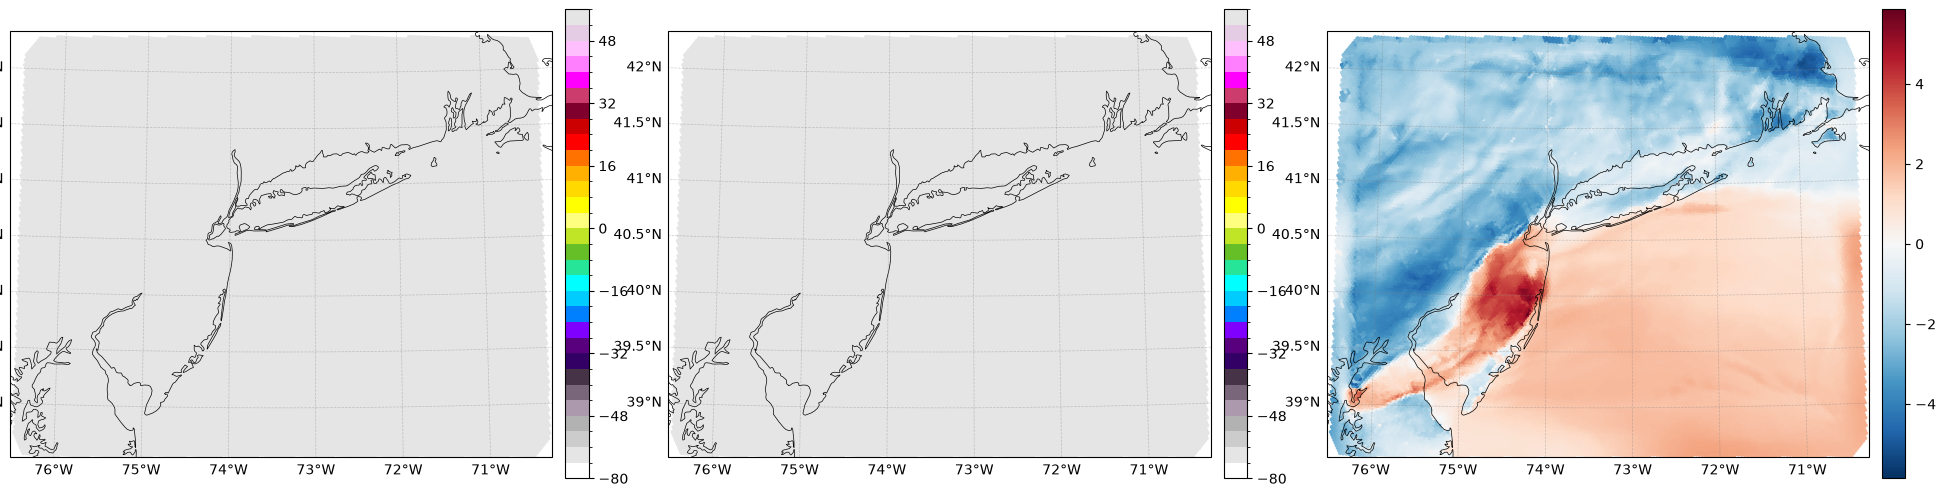

In [6]:
from earthcmap import escmap

# Get the PolyCollections for each panel
cmap_t, norm_t = escmap("temp_ecmwf")
coll_early = mpasd.collection(dta, var_name='t2m', time_index=0, figsize=(6,6), cmap=cmap_t, norm=norm_t)
coll_late  = mpasd.collection(dta, var_name='t2m', time_index=12, figsize=(6,6), cmap=cmap_t, norm=norm_t)

# For the difference, use a diverging colormap centered on zero
vmax_diff = max(abs(float(t_diff.min())), abs(float(t_diff.max())))
cmap_diff = plt.cm.RdBu_r
norm_diff = colors.TwoSlopeNorm(vmin=-vmax_diff, vcenter=0, vmax=vmax_diff)

# Build the difference collection manually
coll_diff = mpasd.collection_base(dta, crs=coll_early.crs, figsize=(6,6))
coll_diff.set_array(t_diff.values.flatten())
coll_diff.set_cmap(cmap_diff)
coll_diff.set_norm(norm_diff)
coll_diff.set_edgecolor('face')

# Create three-panel figure
fig, axes = plt.subplots(1, 3, figsize=(20, 7),
                         subplot_kw={'projection': coll_early.crs})

panels = [
    (axes[0], coll_early, cmap_t, norm_t, f"T\u2082\u2098 \u2014 {times[0]}"),
    (axes[1], coll_late,  cmap_t, norm_t, f"T\u2082\u2098 \u2014 {times[12]}"),
    (axes[2], coll_diff,  cmap_diff, norm_diff, "\u0394T\u2082\u2098 (Late \u2212 Early)"),
]

for ax, coll, cmap, norm, title in panels:
    ax.add_collection(coll)
    ax.autoscale_view()
    ax.coastlines(linewidth=0.5)
    ax.set_extent(coll_early.limits, crs=ccrs.PlateCarree())
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=0.5, color='gray', alpha=0.4, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    ax.set_title(title)
    fig.colorbar(coll, ax=ax, shrink=0.7, pad=0.02)

# Patch all GeoAxes for Jupyter inline backend compatibility
for ax in axes:
    _orig = ax.get_tightbbox
    def _patch(renderer=None, _orig=_orig, _ax=ax, **kw):
        bbox = _orig(renderer=renderer, **kw)
        if bbox is None or not np.isfinite(bbox.bounds).all():
            return _ax.get_window_extent(renderer)
        return bbox
    ax.get_tightbbox = _patch

plt.tight_layout()

## Precipitation Accumulation Difference

Visualizing the rain rate field to observe precipitation evolution during the storm.

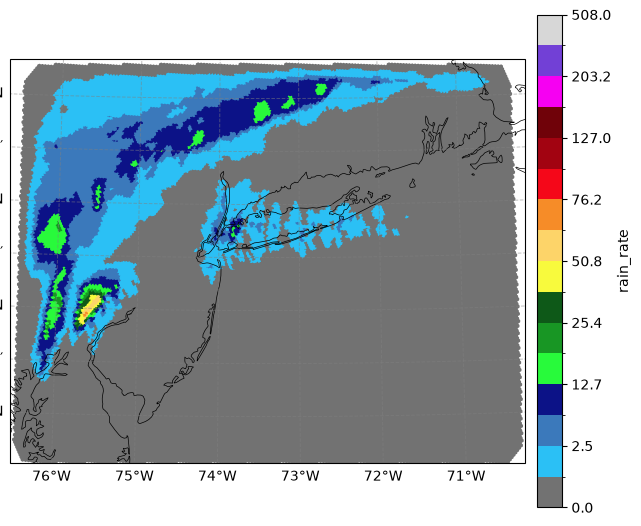

In [7]:
# Compare rain accumulation: early vs peak of storm
cmap_r, norm_r = escmap("nwps_qpe", units="mm")

mpasd.show(dta, var_name='rain_rate', time_index=6, figsize=(8, 8), cmap=cmap_r, norm=norm_r)

## Computing Custom Derived Fields

Since `mpasviewer` works with xarray datasets, you can perform arbitrary computations on the data arrays and then pass the results back to the viewer. Here we compute 10-meter wind speed from the U and V components.

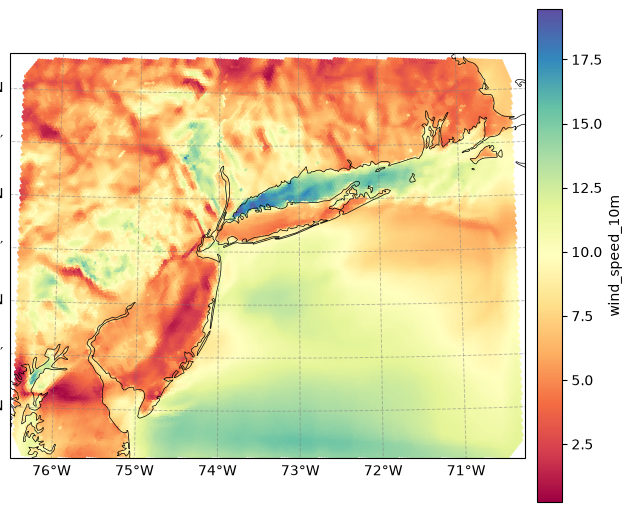

In [8]:
# Compute wind speed from u10/v10 components
wind_speed = np.sqrt(dta['u10']**2 + dta['v10']**2)
wind_speed.attrs = {'long_name': 'Wind Speed 10m', 'units': 'm s\u207b\u00b9', 'var_name': 'wind_speed_10m'}

# Add to dataset
dta['wind_speed_10m'] = wind_speed

# Show wind speed at peak storm time
mpasd.show(dta, var_name='wind_speed_10m', time_index=12, figsize=(8, 8))